In [180]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.tree import DecisionTreeClassifier

from decimal import getcontext, Decimal
# Set the global precision to 2 decimal places
getcontext().prec = 3

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv('diabetes.csv')

In [26]:
df['Outcome'].value_counts(normalize=True)

0    0.651042
1    0.348958
Name: Outcome, dtype: float64

In [9]:
X,y=df.drop('Outcome',axis=1),df['Outcome']

In [23]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,shuffle=True)

In [27]:
y_train.value_counts(normalize=True)

0    0.643322
1    0.356678
Name: Outcome, dtype: float64

In [109]:
num_node=[]
num_leaf=[]
num_decisions=[]
min_samples_split=[]
min_samples_leaf=[]
max_depth=[]
max_leaf_nodes=[]
max_features=[]
train_acc=[]
test_acc=[]

In [126]:
clf = DecisionTreeClassifier(random_state=42,max_depth=5,min_samples_split=15,min_samples_leaf=25,max_leaf_nodes=10,
                            max_features=0.5)
clf.fit(X_train, y_train)


tree_info = clf.tree_
num_nodes = tree_info.node_count
num_leaves = tree_info.n_leaves
num_decision = num_nodes - num_leaves




num_node.append(num_nodes)
num_leaf.append(num_leaves)
num_decisions.append(num_decision)
min_samples_split.append(clf.min_samples_split)
min_samples_leaf.append(clf.min_samples_leaf)
max_depth.append(clf.get_params()['max_depth'])
max_leaf_nodes.append(clf.get_params()['max_leaf_nodes'])
max_features.append(clf.get_params()['max_features'])
train_acc.append(clf.score(X_train, y_train))
test_acc.append(clf.score(X_test, y_test))


results_df=pd.DataFrame({"Number of nodes":num_node,
     "Number of leaves":num_leaf,
    "Number of decisions":num_decisions,
    "Min samples split":min_samples_split,
    "Min samples leaf":min_samples_leaf,
    "Max depth":max_depth,
    "Max leaf nodes":max_leaf_nodes,
    "Max features":max_features,
    "Training Accuracy":train_acc,
    "Testing Accuracy":test_acc
             })

results_df

,Number of nodes,Number of leaves,Number of decisions,Min samples split,Min samples leaf,Max depth,Max leaf nodes,Max features,Training Accuracy,Testing Accuracy
0,219,110,109,2,1,NaN,NaN,None,1.000000,0.727273
1,15,8,7,2,1,3.0,NaN,None,0.796417,0.753247
2,55,28,27,2,1,5.0,NaN,None,0.840391,0.753247
3,145,73,72,2,1,8.0,NaN,None,0.938111,0.746753
4,53,27,26,10,1,5.0,NaN,None,0.838762,0.753247
5,47,24,23,15,1,5.0,NaN,None,0.825733,0.772727
6,45,23,22,20,1,5.0,NaN,None,0.824104,0.759740
7,25,13,12,15,35,5.0,NaN,None,0.785016,0.746753
8,31,16,15,15,25,5.0,NaN,None,0.794788,0.792208
9,11,6,5,15,25,5.0,6.0,None,0.776873,0.753247


In [139]:
results_df[results_df['Testing Accuracy']==results_df['Testing Accuracy'].max()]

,Number of nodes,Number of leaves,Number of decisions,Min samples split,Min samples leaf,Max depth,Max leaf nodes,Max features,Training Accuracy,Testing Accuracy
8,31,16,15,15,25,5.0,NaN,None,0.794788,0.792208
10,19,10,9,15,25,5.0,10.0,None,0.794788,0.792208
11,29,15,14,15,25,5.0,15.0,None,0.794788,0.792208
12,23,12,11,15,25,5.0,12.0,None,0.794788,0.792208


In [140]:
results_df[results_df['Testing Accuracy']==results_df['Testing Accuracy'].max()].iloc[1,:]

Number of nodes              19
Number of leaves             10
Number of decisions           9
Min samples split            15
Min samples leaf             25
Max depth                   5.0
Max leaf nodes             10.0
Max features               None
Training Accuracy      0.794788
Testing Accuracy       0.792208
Name: 10, dtype: object

### This is the best model since the testing accuracy is maximum.It has converged with the training accuracy, which suggests that it is the best fit model. We did not choose any other model with similar accuracy since this modelis the least complex of them all.A model with 19 nodes and 10 leaves is less complex than a model with greater number of nodes and leaves.

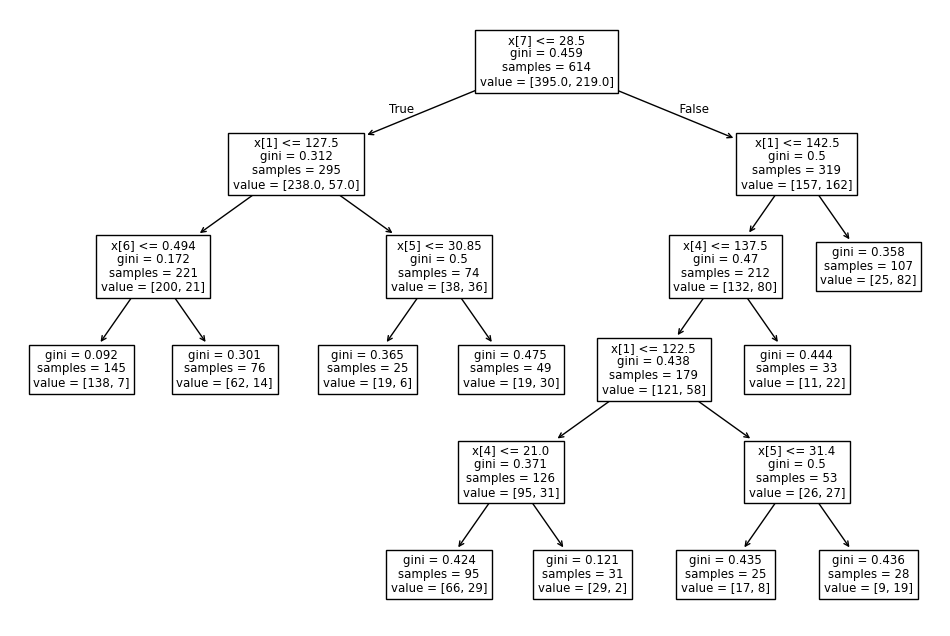

In [161]:
plt.figure(figsize=(12,8))
plot_tree(clf)
plt.show()

In [183]:
n_nodes = clf.tree_.node_count
children_left = clf.tree_.children_left
children_right = clf.tree_.children_right
feature = clf.tree_.feature
threshold = clf.tree_.threshold
values = clf.tree_.value
impurity=clf.tree_.impurity

node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
is_leaves = np.zeros(shape=n_nodes, dtype=bool)
stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
while len(stack) > 0:
    # `pop` ensures each node is only visited once
    node_id, depth = stack.pop()
    node_depth[node_id] = depth

    # If the left and right child of a node is not the same we have a split
    # node
    is_split_node = children_left[node_id] != children_right[node_id]
    # If a split node, append left and right children and depth to `stack`
    # so we can loop through them
    if is_split_node:
        stack.append((children_left[node_id], depth + 1))
        stack.append((children_right[node_id], depth + 1))
    else:
        is_leaves[node_id] = True

print(
    "The binary tree structure has {n} nodes and has "
    "the following tree structure:\n".format(n=n_nodes)
)
for i in range(n_nodes):
    if is_leaves[i]:
        print(
            "{space}node={node} is a leaf node with value={value}.".format(
                space=node_depth[i] * "\t", node=i, value=np.around(values[i],4)
            )
        )
    else:
        print(
            "{space}node={node} is a split node with value={value}: "
            "go to node {left} if X[:, {feature}] <= {threshold} "
            "else to node {right}.".format(
                space=node_depth[i] * "\t",
                node=i,
                left=children_left[i],
                feature=feature[i],
                threshold=threshold[i],
                right=children_right[i],
                value=np.around(values[i],4),
            )
        )

The binary tree structure has 19 nodes and has the following tree structure:

node=0 is a split node with value=[[0.6433 0.3567]]: go to node 1 if X[:, 7] <= 28.5 else to node 2.
	node=1 is a split node with value=[[0.8068 0.1932]]: go to node 5 if X[:, 1] <= 127.5 else to node 6.
	node=2 is a split node with value=[[0.4922 0.5078]]: go to node 3 if X[:, 1] <= 142.5 else to node 4.
		node=3 is a split node with value=[[0.6226 0.3774]]: go to node 7 if X[:, 4] <= 137.5 else to node 8.
		node=4 is a leaf node with value=[[0.2336 0.7664]].
		node=5 is a split node with value=[[0.905 0.095]]: go to node 17 if X[:, 6] <= 0.494499996304512 else to node 18.
		node=6 is a split node with value=[[0.5135 0.4865]]: go to node 11 if X[:, 5] <= 30.850000381469727 else to node 12.
			node=7 is a split node with value=[[0.676 0.324]]: go to node 9 if X[:, 1] <= 122.5 else to node 10.
			node=8 is a leaf node with value=[[0.3333 0.6667]].
				node=9 is a split node with value=[[0.754 0.246]]: go to no

In [199]:
feat_imp={name:imp for name,imp in zip(X_train.columns,list(clf.feature_importances_))}

In [204]:
feat_imp=dict(sorted(feat_imp.items(), key=lambda item: item[1]))

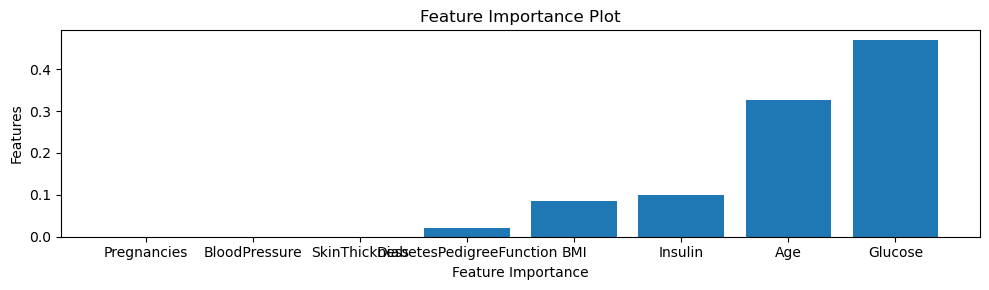

In [213]:
plt.figure(figsize=(10, 3))
plt.bar(list(feat_imp.keys()), list(feat_imp.values()))
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance Plot")
plt.tight_layout()
plt.show()

In [220]:
import itertools

lst=[]
for i in itertools.combinations(np.arange(0,7),r=2):
    lst.append(list(i))

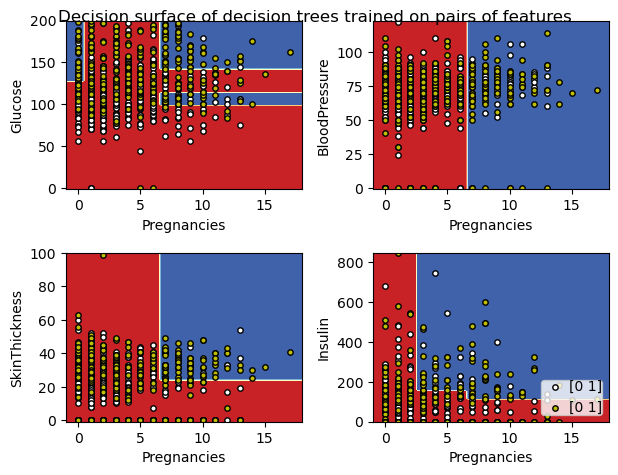

In [251]:
from sklearn.inspection import DecisionBoundaryDisplay


# Parameters
n_classes = 2
plot_colors = "wy"
plot_step = 0.02


for pairidx, pair in enumerate(lst[0:4]):
    # We only take the two corresponding features
    X_new = np.array(X)[:, pair]
    clf = DecisionTreeClassifier(random_state=42,max_depth=5,min_samples_split=15,min_samples_leaf=25,max_leaf_nodes=10,
                            max_features=0.5).fit(X_new, y)
    
    # Plot the decision boundary
    ax = plt.subplot(2, 2, pairidx + 1,)
    plt.tight_layout()
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X_new,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=X.columns[pair[0]],
        ylabel=X.columns[pair[1]],
    )

    # Plot the training points
    for i, color in zip(range(len(clf.classes_)), plot_colors):
        idx = np.asarray(y == i).nonzero()
        plt.scatter(
            X_new[idx, 0],
            X_new[idx, 1],
            c=color,
            label=clf.classes_,
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

In [273]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.03036828, random_state=42)

In [274]:
clf.score(X_test,y_test)

0.7532467532467533

In [253]:
ccp_alphas= clf.cost_complexity_pruning_path(X_train, y_train)['ccp_alphas']

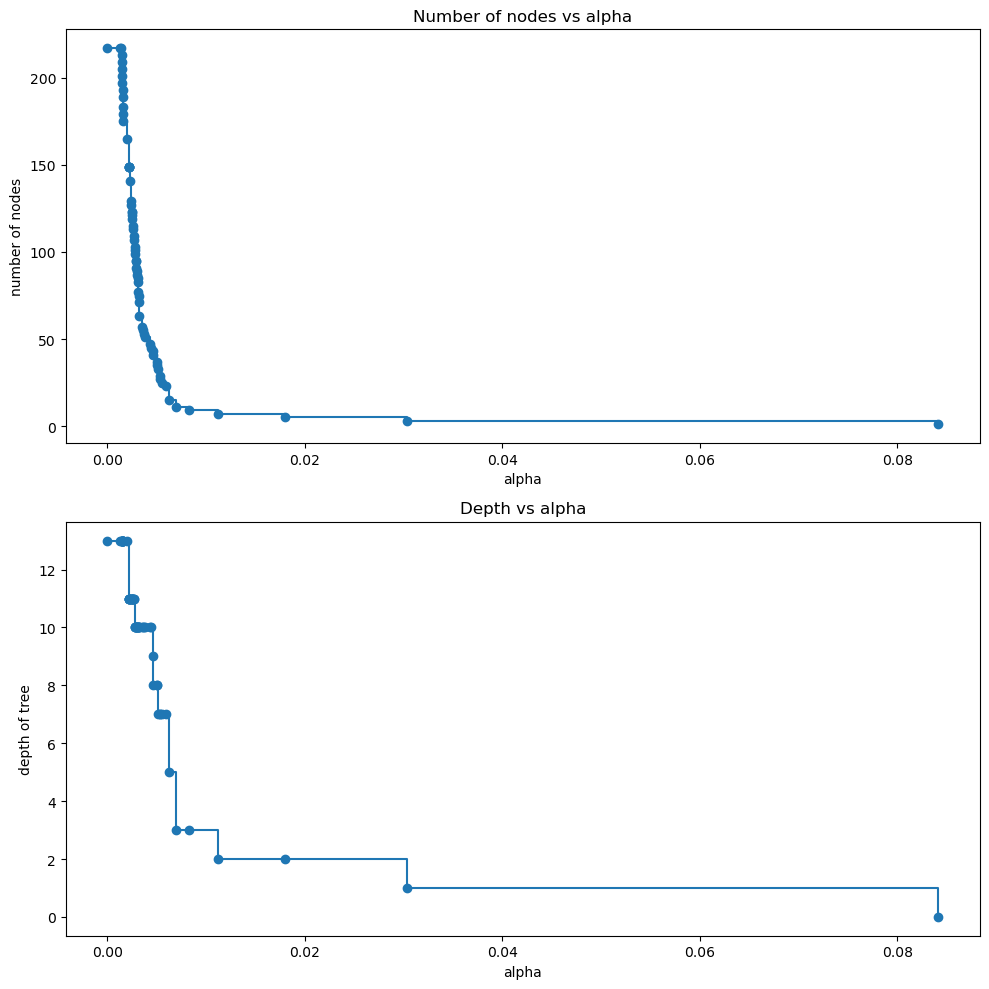

In [257]:
clf_dts = []#created an array that we put decision tree into

for ccp_alpha in ccp_alphas :
    clf=DecisionTreeClassifier(random_state = 0, ccp_alpha = ccp_alpha)
    clf.fit(X_train, y_train)
    clf_dts.append(clf)
train_scores= [ clf.score(X_train, y_train) for  clf in clf_dts]
test_scores = [clf.score(X_test, y_test) for clf in clf_dts]
node_counts = [clf.tree_.node_count for clf in clf_dts]
depth = [clf.tree_.max_depth for clf in clf_dts]
fig, ax = plt.subplots(2, 1, figsize =(10,10))
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
## We can see that as the value of ccp_alpha increases, the depth of the tree and number of nodes decreases, leading to a simpler tree.

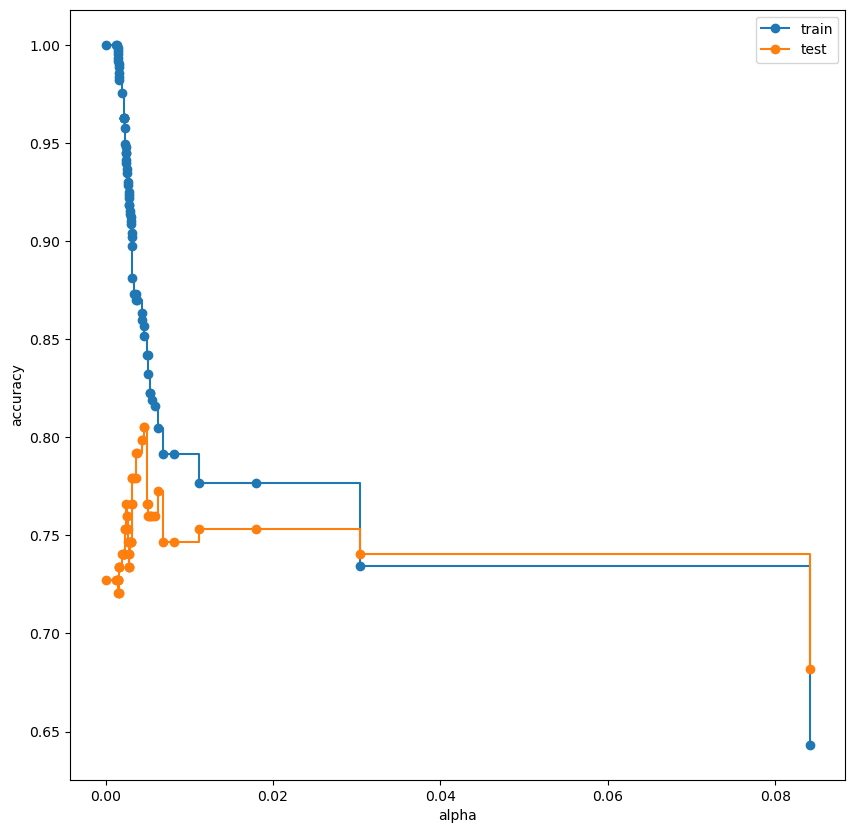

In [258]:
fig, ax = plt.subplots(figsize=(10,10))
ax.set_xlabel('alpha')
ax.set_ylabel('accuracy')
ax.plot(ccp_alphas, train_scores, marker = 'o' , label='train', drawstyle = 'steps-post')
ax.plot(ccp_alphas, test_scores, marker = 'o' , label='test', drawstyle = 'steps-post')

ax.legend()
plt.show()

### ## Best ccp_alpha value, it is the value for which the train and test accuracies are the closest.

In [272]:
ccp_alphas[(ccp_alphas>0.02) & (ccp_alphas<0.04)] ## Best ccp_alpha value, it is the value for which the train and test accuracies are the closest.

array([0.03036828])

In [275]:
clf = DecisionTreeClassifier(random_state=42,ccp_alpha=0.03036828)
clf.fit(X_train, y_train)
clf.score(X_test,y_test)

0.7532467532467533